### Simple properties that require single computations



There are many properties that only require a single DFT calculation to obtain the energy, forces, density of states, electron density and electrostatic potential. This section describes some of these calculations and their analysis.



#### Energy and forces



Two of the most important quantities we are interested in are the total
energy and the forces on the atoms. To get these quantities, we have
to define a calculator and attach it to an mod:ase.Atoms object so
that `ase` knows how to get the data. After defining the calculator a
DFT calculation must be run.

Here is an example of getting the energy and forces from a CO
molecule. The forces in this case are very high, indicating that this
geometry is not close to the ground state geometry. Note that the
forces are only along the $x$-axis, which is along the molecular axis. We will see how to minimize this force in [BROKEN LINK: \*Manual%20determination%20of%20a%20bond%20length] and [BROKEN LINK: \*Automatic%20geometry%20optimization%20with%20VASP].

<div class="note" id="org8e4d957">
<p>
This is your first DFT calculation in the book! See [BROKEN LINK: incar:ISMEAR], incar:SIGMA, incar:NBANDS, and incar:ENCUT to learn more about these VASP keywords.
</p>

</div>



In [22]:
from ase import Atoms, Atom
from vasp import Vasp

co = Atoms([Atom('C', [0, 0, 0]),
            Atom('O', [1.2, 0, 0])],
           cell=(6., 6., 6.))

calc = Vasp(label='molecules/simple-co',  # output dir
            xc='pbe',  # the exchange-correlation functional
            nbands=6,    # number of bands
            encut=350,    # planewave cutoff
            ismear=1,    # Methfessel-Paxton smearing
            sigma=0.01,  # very small smearing factor for a molecule
            atoms=co)

print('energy = {0} eV'.format(co.get_potential_energy()))
print(co.get_forces())

energy = -14.69072754 eV
[[ 5.091  0.    -0.   ]
 [-5.091 -0.     0.   ]]


We can see what files were created and used in this calculation by printing the vasp attribute of the calculator.



In [23]:
from vasp import Vasp
calc = Vasp(label='molecules/simple-co')
# Check if calculation directory exists
import os
print(os.path.exists('molecules/simple-co'))

True


##### Running a job in parallel



In [24]:
from ase import Atoms, Atom
from vasp import Vasp
# from vasp.vasprc import VASPRC  # Deprecated in new vasp

# # VASPRC['queue.ppn'] = 4  # Deprecated in new vasp  # Deprecated in new vasp

co = Atoms([Atom('C', [0, 0, 0]),
            Atom('O', [1.2, 0, 0])],
           cell=(6., 6., 6.))

calc = Vasp(label='molecules/simple-co-n4',  # output dir
            xc='PBE',  # the exchange-correlation functional
            nbands=6,    # number of bands
            encut=350,    # planewave cutoff
            ismear=1,    # Methfessel-Paxton smearing
            sigma=0.01,  # very small smearing factor for a molecule
            atoms=co)

print('energy = {0} eV'.format(co.get_potential_energy()))
print(co.get_forces())

energy = -14.69072754 eV
[[ 5.091  0.    -0.   ]
 [-5.091 -0.     0.   ]]


##### Convergence with unit cell size



There are a number of parameters that affect the energy and forces including the calculation parameters and the unit cell. We will first consider the effect of the unit cell on the total energy and forces. The reason that the unit cell affects the total energy is that it can change the distribution of electrons in the molecule.



In [25]:
from vasp import Vasp
from ase import Atoms, Atom
import numpy as np
np.set_printoptions(precision=3, suppress=True)

atoms = Atoms([Atom('C', [0, 0, 0]),
               Atom('O', [1.2, 0, 0])])

L = [4, 5, 6, 8, 10]

for a in L:
    atoms.set_cell([a, a, a], scale_atoms=False)
    atoms.center()
    calc = Vasp(label='molecules/co-L-{0}'.format(a),
                xc='PBE',
                encut=350,
                atoms=atoms)
    try:
        atoms_out = calc.get_atoms()
        print('{0} {1}'.format(a, atoms_out.get_potential_energy()))
    except Exception as e:
        print('{0} not ready: {1}'.format(a, e))

4 -15.35943421
5 -14.85641879
6 -14.68750603
8 -14.63193135
10 -14.65343306


![img](./images/co-e-v.png "Total energy of a CO molecule as a function of the unit cell length.")

Here there are evidently attractive interactions between the CO molecules which lower the total energy for small box sizes. We have to decide what an appropriate volume for our calculation is, and the choice depends on the goal. We may wish to know the total energy of a molecule that is not interacting with any other molecules, e.g. in the ideal gas limit. In that case we need a large unit cell so the electron density from the molecule does not go outside the unit cell where it would overlap with neighboring images.

It pays to check for convergence. The cost of running the calculation goes up steeply with increasing cell size. Doubling a lattice vector here leads to a 20-fold increase in computational time! Note that doubling a lattice vector length increases the volume by a factor of 8 for a cube. The cost goes up because the number of planewaves that fit in the cube grows as the cube gets larger.



In [26]:
from vasp import Vasp
import os

L = [4, 5, 6, 8, 10]

for a in L:
    directory = 'molecules/co-L-{0}'.format(a)
    if os.path.exists(os.path.join(directory, 'OUTCAR')):
        print('{0} calculation exists'.format(a))
    else:
        print('{0} not found'.format(a))

4 calculation exists
5 calculation exists
6 calculation exists
8 calculation exists
10 calculation exists


Let us consider what the pressure in the unit cell is. In the ideal gas limit we have $PV = nRT$, which gives a pressure of zero at absolute zero. At non-zero temperatures, we have $P=n/V RT$. Let us consider some examples. In atomic units we use $k_B$ instead of $R$.



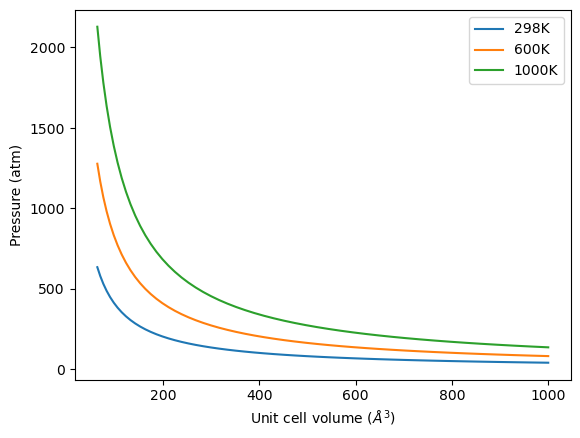

In [27]:
from ase.units import kB, Pascal
import numpy as np
import matplotlib.pyplot as plt

atm = 101325 * Pascal

L = np.linspace(4, 10)
V = L**3

n = 1  # one atom/molecule per unit cell

for T in [298, 600, 1000]:
    P = n / V * kB * T / atm  # convert to atmospheres

    plt.plot(V, P, label='{0}K'.format(T))

plt.xlabel('Unit cell volume ($\AA^3$)')
plt.ylabel('Pressure (atm)')
plt.legend(loc='best')


![img](./images/ideal-gas-pressure.png "Ideal gas pressure dependence on temperature and unit cell volume.")



##### Convergence of ENCUT



The total energy and forces also depend on the computational parameters, notably incar:ENCUT.



In [28]:
from ase import Atoms, Atom
from vasp import Vasp
import numpy as np
np.set_printoptions(precision=3, suppress=True)

atoms = Atoms([Atom('C', [0, 0, 0]),
               Atom('O', [1.2, 0, 0])],
              cell = (6, 6, 6))
atoms.center()

calc = Vasp(label='molecules/simple-co',
            xc='PBE',
            encut=350,
            atoms=atoms)

try:
    atoms = calc.get_atoms()
    print('potential energy = {0} eV'.format(atoms.get_potential_energy()))
    print('forces (eV/Ang):')
    print(atoms.get_forces())
except Exception as e:
    print('Calculation not ready: {}'.format(e))

potential energy = -14.69072754 eV
forces (eV/Ang):
[[ 5.091  0.    -0.   ]
 [-5.091 -0.     0.   ]]


![img](./images/co-encut-v.png "Dependence of the total energy of CO molecule on ENCUT.")

You can see in this figure that it takes a cutoff energy of about 400 eV to achieve a convergence level around 10 meV, and that even at 500 meV the energy is still changing slightly. Keep in mind that we are generally interested in differences in total energy, and the differences tend to converge faster than a single total energy. Also it is important to note that it is usually a single element that determines the rate of convergence. The reason we do not just use very high ENCUT all the time is it is expensive.


In [29]:
! grep "Elapsed time (sec):" molecules/co-en-*/OUTCAR

molecules/co-en-250/OUTCAR:                         Elapsed time (sec):        1.156
molecules/co-en-300/OUTCAR:                         Elapsed time (sec):        1.314
molecules/co-en-350/OUTCAR:                         Elapsed time (sec):        1.508
molecules/co-en-400/OUTCAR:                         Elapsed time (sec):        1.456
molecules/co-en-450/OUTCAR:                         Elapsed time (sec):        1.532
molecules/co-en-500/OUTCAR:                         Elapsed time (sec):        1.888


##### Cloning



You may want to clone a calculation, so you can change some parameter without losing the previous result. The clone function does this, and changes the calculator over to the new directory.



In [30]:
from ase import Atoms, Atom
from vasp import Vasp

calc = Vasp(label='molecules/simple-co')
print('energy = {0} eV'.format(calc.get_potential_energy()))

# This creates the directory and makes it current working directory
calc = calc.clone('molecules/clone-1')
calc.set(encut=325)  
print(calc)

print('energy = {0} eV'.format(calc.get_potential_energy()))

energy = -14.69072754 eV
Vasp('/home/jovyan/dft-book/notebooks/03-molecules/molecules/clone-1', xc='PBE')
energy = -14.76731013 eV


#### Visualizing electron density



The electron density is a 3$d$ quantity: for every $(x,y,z)$ point, there is a charge density. That means we need 4 numbers for each point: $(x,y,z)$ and $\rho(x,y,z)$. Below we show an example (Figure ref:fig:cd1) of plotting the charge density, and we consider some issues we have to consider when visualizing volumetric data in unit cells with periodic boundary conditions. We will use the results from a previous calculation.



In [31]:
calc = Vasp(label='molecules/simple-co')
calc = calc.clone('molecules/co-chg')
calc.set(lcharg=True)
calc.calculate()

atoms = calc.load_atoms()
(x,y,z), cd = calc.get_charge_density()
cd.shape

(60, 60, 60)

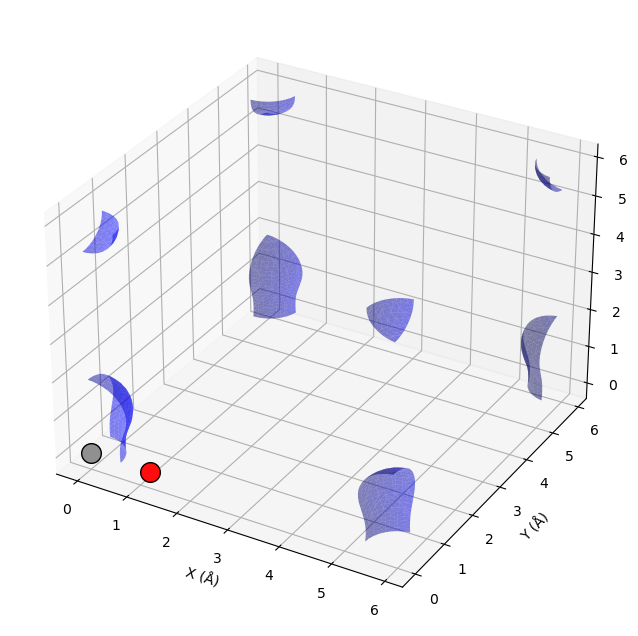

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
from vasp import Vasp

# Get charge density
grid_points, density = calc.get_charge_density()
cell = calc.atoms.get_cell()

# Create isosurface using marching cubes
isovalue = density.max() * 0.1  # Adjust as needed
verts, faces, _, _ = measure.marching_cubes(density, isovalue)

# Convert fractional to Cartesian coordinates
ngx, ngy, ngz = density.shape
verts_frac = verts / np.array([ngx, ngy, ngz])
verts_cart = verts_frac @ cell

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot isosurface
ax.plot_trisurf(verts_cart[:, 0], verts_cart[:, 1], faces, verts_cart[:, 2],
                  alpha=0.5, color='blue')

# Plot atoms
from ase.data.colors import jmol_colors
for atom in calc.atoms:
    color = jmol_colors[atom.number]
    ax.scatter(*atom.position, s=200, c=[color], edgecolors='black')

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)');


In [33]:
from vasp import Vasp
from ase.visualize import view
from ase.io import write
from ase import Atom, Atoms

atoms = Atoms([Atom('C', [2.422, 0.0, 0.0]),
               Atom('O', [3.634, 0.0, 0.0])],
              cell=[6.0, 6.0, 6.0])

# Save as image instead of 3D visualization
write('images/co-atoms.png', atoms, show_unit_cell=2)
print('Structure saved to images/co-atoms.png')

atoms = Atoms([Atom('C', [2.422, 0.0, 0.0]),
               Atom('O', [3.578, 0.0, 0.0])],
               cell=(10,10,10))

atoms.center()

calc = Vasp(label='molecules/co-centered',
            encut=350,
            xc='PBE',
            atoms=atoms)
calc.set(lcharg=True,)
calc.calculate()

Structure saved to images/co-atoms.png


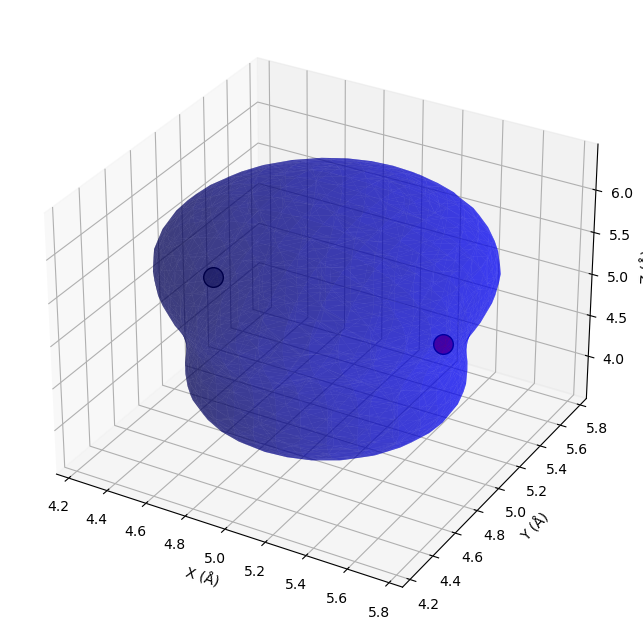

In [34]:
# Get charge density
grid_points, density = calc.get_charge_density()
cell = calc.atoms.get_cell()

# Create isosurface using marching cubes
isovalue = density.max() * 0.1  # Adjust as needed
verts, faces, _, _ = measure.marching_cubes(density, isovalue)

# Convert fractional to Cartesian coordinates
ngx, ngy, ngz = density.shape
verts_frac = verts / np.array([ngx, ngy, ngz])
verts_cart = verts_frac @ cell

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot isosurface
ax.plot_trisurf(verts_cart[:, 0], verts_cart[:, 1], faces, verts_cart[:, 2],
                  alpha=0.5, color='blue')

# Plot atoms
from ase.data.colors import jmol_colors
for atom in calc.atoms:
    color = jmol_colors[atom.number]
    ax.scatter(*atom.position, s=200, c=[color], edgecolors='black')

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)');

#### Dipole moments



The [dipole moment](http://en.wikipedia.org/wiki/Molecular_dipole_moment#Molecular_dipoles) is a vector describing the separation of  electrical (negative) and nuclear (positive) charge. The magnitude of this vector is the dipole moment, which has units of Coulomb-meter, or more commonly Debye. The symmetry of a molecule determines if a molecule has a dipole moment or not. 

In [35]:
from vasp import Vasp
from ase import Atoms, Atom
import numpy as np
from ase.units import Debye

atoms = Atoms([Atom('C', [0, 0, 0]),
                 Atom('O', [1.2, 0, 0])],
                cell=(6, 6, 6))
atoms.center()

calc = Vasp(label='molecules/co-dipole',
              atoms=atoms,
              xc='PBE',
              encut=400,
              ldipol=True,   # Enable dipole calculation
              idipol=4,      # All directions
              )

energy = calc.potential_energy  # Run calculation
dipole = calc.get_dipole_moment()

dipole_eA = calc.get_dipole_moment()  # in e·Å
dipole_magnitude = np.linalg.norm(dipole_eA)
dipole_debye = dipole_magnitude / Debye

print(f'{dipole_magnitude:.4f} e·Å = {dipole_debye:.4f} Debye')
 

0.0264 e·Å = 0.1267 Debye


#### The density of states (DOS)



The density of states (DOS) gives you the number of electronic states (i.e., the orbitals) that have a particular energy. We can get this information from the last calculation we just ran without having to run another DFT calculation.



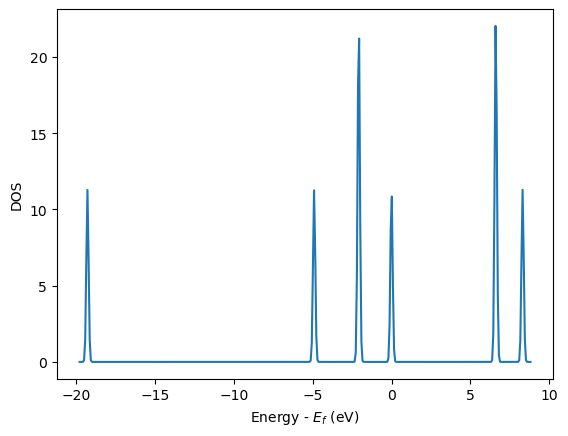

In [36]:
from vasp import Vasp
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

calc = Vasp(label='molecules/simple-co')   # we already ran this!
dos = DOS(calc)
plt.plot(dos.get_energies(), dos.get_dos())
plt.xlabel('Energy - $E_f$ (eV)')
plt.ylabel('DOS')

# make sure you save the figure outside the with statement, or provide
# the correct relative or absolute path to where you want it.


#### Atom-projected density of states on molecules



Let us consider which states in the density of states belong to which atoms in a molecule. This can only be a qualitative consideration because the orbitals on the atoms often hybridize to form molecular orbitals, e.g. in methane the $s$ and $p$ orbitals can form what we call $sp^3$ orbitals. We can compute atom-projected density of states in VASP, which is done by projecting the wave function onto localized atomic orbitals. Here is an example. We will consider the CO molecule. To get atom-projected density of states, we must set [BROKEN LINK: incar:RWIGS] for each atom. This parameter defines the radius of the sphere around the atom which cuts off the projection. The total density of states and projected density of states information comes from the DOSCAR file.

Note that unlike the DOS, here we must run another calculation because we did not specify the atom-projected keywords above. Our strategy is to get the atoms from the previous calculation, and use them in a new calculation. You could redo the calculation in the same directory, but you risk losing the results of the first step. That can make it difficult to reproduce a result. We advocate our approach of using multiple directories for the subsequent calculations, because it leaves a clear trail of how the work was done.

<div class="note" id="org8f2520a">
<p>
The RWIGS are not uniquely determined for an element. There are various natural choices, e.g. the ionic radius of an atom, or a value that minimizes overlap of neighboring spheres, but these values can change slightly in different environments.
</p>

<p>
You can also get spin-polarized atom-projected DOS, and magnetization projected DOS. See [VASP DOSCAR documentation](http://cms.mpi.univie.ac.at/vasp/vasp/DOSCAR_file.html#doscar)for more details.
</p>

</div>



In [37]:
! rm -fr molecules/co-ados

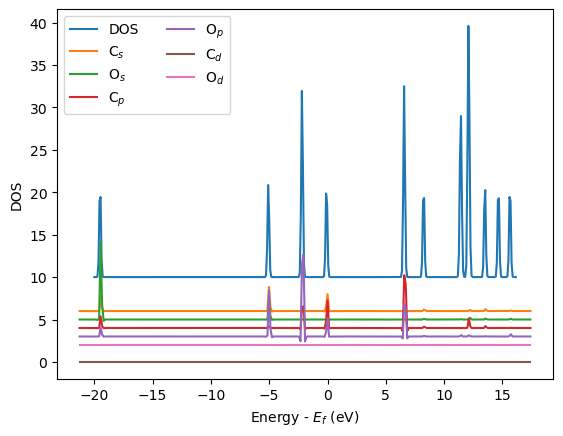

In [38]:
from vasp import Vasp
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

# get the geometry from another calculation
calc = Vasp(label='molecules/simple-co')
atoms = calc.load_atoms()

calc = Vasp(label='molecules/co-ados',
            encut=300,
            xc='PBE',
            rwigs={'C': 1.0, 'O': 1.0},     # these are the cutoff radii for projected states
            lorbit=11,  # Required for projected DOS
            atoms=atoms)

calc.calculate()

# now get results
dos = DOS(calc)
plt.plot(dos.get_energies(), dos.get_dos() + 10)

energies, c_s = calc.get_ados(0, 's')
_, c_p = calc.get_ados(0, 'p')
_, o_s = calc.get_ados(1, 's')
_, o_p = calc.get_ados(1, 'p')

_, c_d = calc.get_ados(0, 'd')
_, o_d = calc.get_ados(1, 'd')

plt.plot(energies, c_s + 6, energies, o_s + 5)
plt.plot(energies, c_p + 4, energies, o_p + 3)
plt.plot(energies, c_d, energies, o_d + 2)
plt.xlabel('Energy - $E_f$ (eV)')
plt.ylabel('DOS')
plt.legend(['DOS',
            'C$_s$', 'O$_s$',
            'C$_p$', 'O$_p$',
            'C$_d$', 'O$_d$'],
           ncol=2, loc='best');

#### Electrostatic potential



This is an example of the so-called &sigma; hole in a [halogen bond](http://pubs.acs.org/cen/science/87/8738sci2.html). The coordinates for the CF<sub>3</sub>Br molecule were found at [http://cccbdb.nist.gov/exp2.asp?casno=75638](http://cccbdb.nist.gov/exp2.asp?casno=75638).



In [39]:
from vasp import Vasp
from ase import Atom, Atoms
from ase.io import write


from ase.data import vdw_radii
from ase.data.colors import cpk_colors

atoms = Atoms([Atom('C',  [ 0.0000,     0.0000,         -0.8088]),
               Atom('Br', [ 0.0000,     0.0000,          1.1146]),
               Atom('F',  [ 0.0000,     1.2455,         -1.2651]),
               Atom('F',  [ 1.0787,    -0.6228,         -1.2651]),
               Atom('F',  [-1.0787,    -0.6228,         -1.2651])],
               cell=(10, 10, 10))
atoms.center()


calc = Vasp(label='molecules/CF3Br',
            encut=350,
            xc='PBE',
            ibrion=1,
            nsw=50,
            lcharg=True,
            lvtot=True,
            lvhar=True,
            atoms=atoms)

calc.set_nbands(f=2)

calc.calculate()
calc.potential_energy

-22.80592672

In [40]:
(x, y, z), lp = calc.get_local_potential()
(x, y, z), cd = calc.get_charge_density()

![img](./images/halogen-ep.png "Plot of the electrostatic potential of CF<sub>3</sub>Br. TODO: figure out how to do an isosurface of charge, colormapped by the local potential.")

See [http://www.uni-due.de/~hp0058/?file=manual03.html&dir=vmdplugins](http://www.uni-due.de/~hp0058/?file=manual03.html&dir=vmdplugins) for examples of using [VMD](http://www.ks.uiuc.edu/Research/vmd/) for visualization.



TODO Bader analysis

```{note} 
You need to install the bader package: https://theory.cm.utexas.edu/henkelman/code/bader/
```


Note: Thanks to @prtkm for helping improve this section ([https://github.com/jkitchin/dft-book/issues/2](https://github.com/jkitchin/dft-book/issues/2)).
Bader analysis is a charge partitioning scheme where charge is divided by surfaces of zero flux that define atomic basins of charge. The most modern way of calculating the Bader charges is using the `bader` program from Graeme Henkelmen's group cite:Henkelman2006354,doi.10.1021/ct100125x. Let us consider a water molecule, centered in a box. The strategy is first to run the calculation, then run the bader program on the results.

We have to specify laechg to be true so that the all-electron core charges will be written out to files. Here we setup and run the calculation to get the densities first.



In [41]:
from vasp import Vasp

from ase.build import molecule
atoms = molecule('H2O')
atoms.center(vacuum=6)

calc = Vasp(label='molecules/h2o-bader',
            xc='PBE',
            encut=350,
            lcharg=True,
            laechg=True,
            atoms=atoms)
print(calc.potential_energy)

-14.22250648


Now that the calculation is done, get the bader code and scripts from [http://theory.cm.utexas.edu/henkelman/code/bader/](http://theory.cm.utexas.edu/henkelman/code/bader/).

We use this code to see the changes in charges on the atoms.



In [45]:
from vasp import Vasp

calc = Vasp(label='molecules/h2o-bader')

calc.bader(ref=True, overwrite=True)
atoms = calc.load_atoms()
for atom in atoms:
    print(f'|{atom.symbol:^5s} | {atom.charge: 4.4f} |')


|  O   | -1.2326 |
|  H   |  0.6161 |
|  H   |  0.6165 |


The results above are comparable to those from gpaw at [https://wiki.fysik.dtu.dk/gpaw/tutorials/bader/bader.html](https://wiki.fysik.dtu.dk/gpaw/tutorials/bader/bader.html).

You can see some charge has been "transferred" from H to O.

